<a href="https://colab.research.google.com/github/JaimeB252019/PRACTICA/blob/main/PRACTICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. IMPORTAR LIBRERIAS


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

2. CARGAR ARCHIVO

In [10]:
df = pd.read_csv('https://raw.githubusercontent.com/JaimeB252019/PRACTICA/refs/heads/main/recursos/Prestige_modificado.csv', delimiter=';')

print("Dataset cargado correctamente")


Dataset cargado correctamente


3. INSPECCION DATASET

In [11]:
# Cantidad de filas y columnas
print("Dimensiones del dataset:")
print(df.shape)

# Primeras filas
print("\nPrimeras filas:")
print(df.head())

# Informacion general
print("\nInformacion del dataset:")
print(df.info())

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset:
(102, 7)

Primeras filas:
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null

4. REVISAR CALIDA DE DATOS


In [12]:
# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

# Registros duplicados
print("\nDuplicados:")
print(df.duplicated().sum())


Valores nulos:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

Duplicados:
0


5. ESTADISTICAS DESCRIPTIVAS

In [13]:
print("\nEstadisticas descriptivas:")
print(df.describe())


Estadisticas descriptivas:
        education        income       women    prestige       census  \
count  102.000000    102.000000  102.000000  102.000000   102.000000   
mean    10.738039   6797.901961   28.979020   46.833333  5401.774510   
std      2.728444   4245.922227   31.724931   17.204486  2644.993215   
min      6.380000    611.000000    0.000000   14.800000  1113.000000   
25%      8.445000   4106.000000    3.592500   35.225000  3120.500000   
50%     10.540000   5930.500000   13.600000   43.600000  5135.000000   
75%     12.647500   8187.250000   52.202500   59.275000  8312.500000   
max     15.970000  25879.000000   97.510000   87.200000  9517.000000   

         type_num  
count  102.000000  
mean     1.843137  
std      0.817447  
min      0.000000  
25%      1.000000  
50%      2.000000  
75%      2.000000  
max      3.000000  


6. MATRIZ CORRELACION

In [14]:
# Seleccionar variables numericas
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

# Calcular correlacion
matriz_correlacion = variables_numericas.corr()

# Mostrar matriz
print("\nMatriz de correlacion:")
print(matriz_correlacion.round(3))

# Correlaciones con Prestige
print("\nCorrelacion con Prestige:")
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))


Matriz de correlacion:
           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000

Correlacion con Prestige:
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


7. COMPARACION EDUCATION VS PRESTIGE

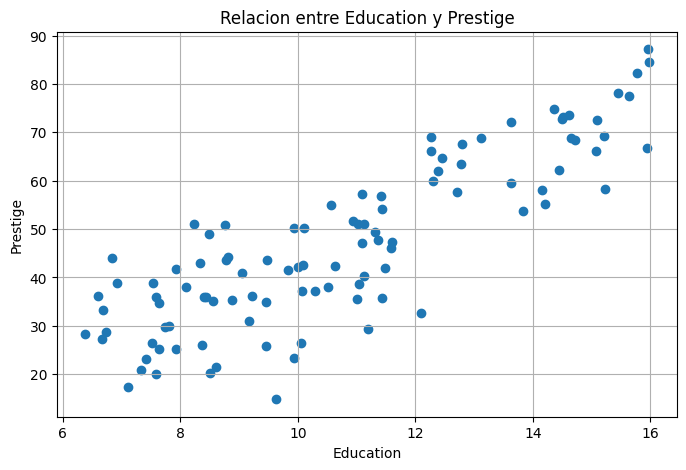

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df['education'], df['prestige'])

plt.xlabel('Education')
plt.ylabel('Prestige')

plt.title('Relacion entre Education y Prestige')

plt.grid(True)

plt.show()

8. COMPARACION INCOME VS PRESTIGE

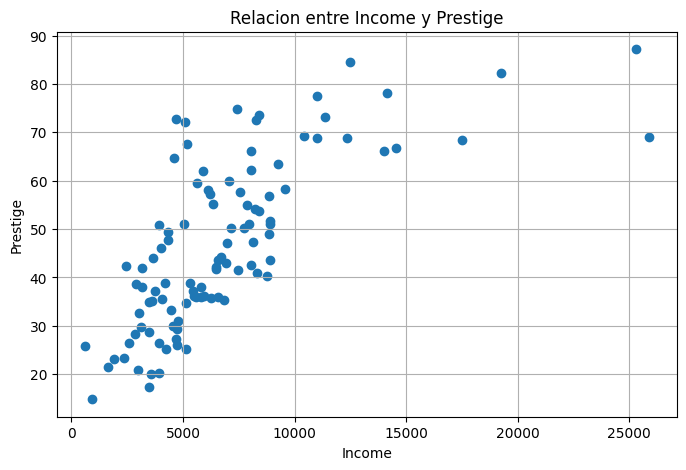

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(df['income'], df['prestige'])

plt.xlabel('Income')
plt.ylabel('Prestige')

plt.title('Relacion entre Income y Prestige')

plt.grid(True)

plt.show()

9. COMPARACION DE PRESTIGIO POR TIPO OCUPACIONAL

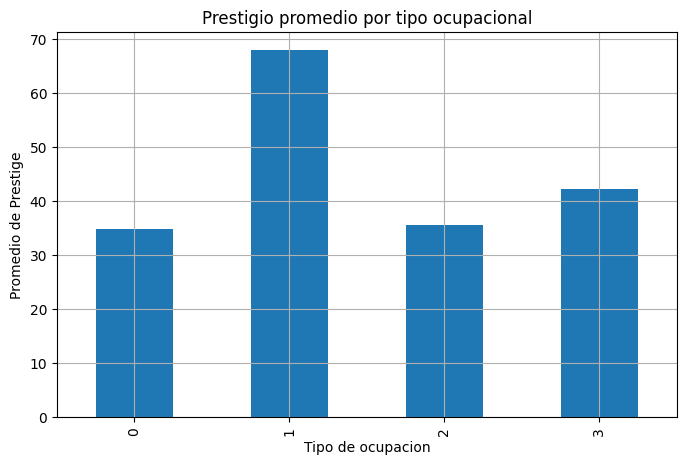

In [22]:
promedio_tipo = df.groupby('type_num')['prestige'].mean()

plt.figure(figsize=(8,5))

promedio_tipo.plot(kind='bar')

plt.xlabel('Tipo de ocupacion')
plt.ylabel('Promedio de Prestige')

plt.title('Prestigio promedio por tipo ocupacional')

plt.grid(True)

plt.show()

10. PREPARAR DATOS PARA CLUSTERIZACION

In [26]:
columnas_cluster = [
    'education',
    'income',
    'women',
    'prestige',
    'type_num'
]

X = df[columnas_cluster].copy()

print(X.head())

   education  income  women  prestige  type_num
0      13.11   12351  11.16      68.8         1
1      12.26   25879   4.02      69.1         1
2      12.77    9271  15.70      63.4         1
3      11.42    8865   9.11      56.8         1
4      14.62    8403  11.68      73.5         1


11. ESCALAR DATOS

In [27]:
escalador = StandardScaler()

X_escalado = escalador.fit_transform(X)

print("Datos escalados correctamente")

Datos escalados correctamente


12. MODELO K-MEANS CON 4 CLUSTERS

In [28]:
modelo_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

print("\nCentroides modelo 4 clusters:")
print(
    df.groupby('Cluster_4')[columnas_cluster]
    .mean()
    .round(2)
)


Centroides modelo 4 clusters:
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


13. MODELO K-MEANS CON 5 CLUSTERS

In [29]:
modelo_k5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print("\nCentroides modelo 5 clusters:")
print(
    df.groupby('Cluster_5')[columnas_cluster]
    .mean()
    .round(2)
)


Centroides modelo 5 clusters:
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


14. VISUALIZAR CLUSTERS

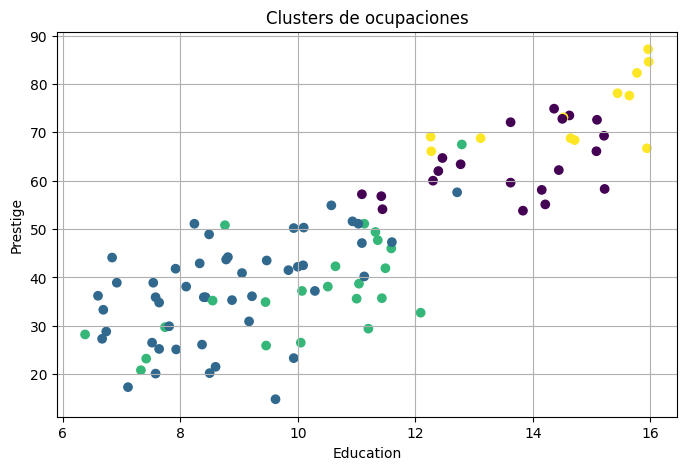

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['education'],
    df['prestige'],
    c=df['Cluster_4']
)

plt.xlabel('Education')
plt.ylabel('Prestige')

plt.title('Clusters de ocupaciones')

plt.grid(True)

plt.show()